In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import rasterio

print("NumPy:", np.__version__)
print("Rasterio:", rasterio.__version__)
sns.set()


NumPy: 1.26.4
Rasterio: 1.3.9


In [2]:
raw_data = pd.read_csv("City_data.csv")


In [3]:
raw_data = raw_data.drop(raw_data.index[13])
raw_data.reset_index(drop=True, inplace=True)
raw_data

,State/UT,City,Latitude,Longitude,Elevation
0,Andhra Pradesh,Amaravati,16.57,80.36,38
1,Andhra Pradesh,Visakhapatnam,17.69,83.22,45
2,Arunachal Pradesh,Itanagar,27.10,93.61,296
3,Arunachal Pradesh,Tawang,27.59,91.86,3048
4,Assam,Dispur,26.14,91.75,60
5,Assam,Silchar,24.83,92.78,22
6,Bihar,Patna,25.59,85.15,53
7,Bihar,Gaya,24.79,85.00,111
8,Chhattisgarh,Raipur,21.25,81.63,298
9,Chhattisgarh,Jagdalpur,19.07,82.02,569


In [4]:
raw_data = raw_data.drop(raw_data.index[47])
raw_data.reset_index(drop=True, inplace=True)
raw_data

,State/UT,City,Latitude,Longitude,Elevation
0,Andhra Pradesh,Amaravati,16.57,80.36,38
1,Andhra Pradesh,Visakhapatnam,17.69,83.22,45
2,Arunachal Pradesh,Itanagar,27.10,93.61,296
3,Arunachal Pradesh,Tawang,27.59,91.86,3048
4,Assam,Dispur,26.14,91.75,60
5,Assam,Silchar,24.83,92.78,22
6,Bihar,Patna,25.59,85.15,53
7,Bihar,Gaya,24.79,85.00,111
8,Chhattisgarh,Raipur,21.25,81.63,298
9,Chhattisgarh,Jagdalpur,19.07,82.02,569


In [5]:
raw_data = raw_data.drop(raw_data.index[47])
raw_data.reset_index(drop=True, inplace=True)

In [6]:
data = raw_data.copy()

In [7]:
coastal_points = {
    "Karachi": (24.860966, 66.990501),
    "Dwarka": (22.244198, 68.968456),
    "Jamnagar": (22.472920, 70.066730),
    "Porbandar": (21.641667, 69.629306),
    "Somnath": (20.915900, 70.373000),
    "Diu": (20.713300, 70.988800),
    "Bhavnagar": (21.764500, 72.151900),
    "Bharuch": (21.705100, 72.995900),
    "Surat": (21.170240, 72.831062),
    "Daman": (20.3974, 72.8328),
    "Palghar": (19.6920, 72.7665),
    "Mumbai": (19.076090, 72.877426),
    "Dapoli": (17.7595, 73.0860),
    "Ratnagiri": (16.990200, 73.3120),
    "Malvan": (16.1047, 73.5126),
    "Panaji": (15.490930, 73.827830),
    "Gokarna": (14.5487, 74.3175),
    "Udupi": (13.3409, 74.7421),
    "Mangaluru": (12.9141, 74.8560),
    "Kannur": (11.8745, 75.3704),
    "Kochi": (9.9312, 76.2673),
    "Kollam": (8.8932, 76.6141),
    "Kanyakumari": (8.0883, 77.5385),
    "Rameshwaram": (9.2880, 79.3120),
    "Thoothukudi": (8.7642, 78.1348),
    "Puducherry": (11.9416, 79.8083),
    "Chennai": (13.0827, 80.2707),
    "Mahabalipuram": (12.6190, 80.1936),
    "Nellore": (14.4426, 79.9865),
    "Ongole": (15.5038, 80.0499),
    "Kakinada": (16.9891, 82.2475),
    "Visakhapatnam": (17.6868, 83.2185),  # Vizag major port city :contentReference[oaicite:1]{index=1}
    "Brahmapur": (19.3143, 84.7941),
    "Puri": (19.8135, 85.8312),
    "Paradeep": (20.2961, 86.5890),
    "Gangasagar": (21.6530, 88.0525),
    "Chattogram": (22.3569, 91.7832),  # Bangladesh port city
    "Port Blair": (11.67, 92.73),
    "Kavaratti": (10.5592344,72.6326215)
}


In [8]:
dist_from_sea = []
Distance_sea = []
i=0
for idx in data.index:
    lat = data.loc[idx, 'Latitude']
    lon = data.loc[idx, 'Longitude']
    for key in coastal_points:
        value = coastal_points[key]
        dist_from_sea.append(((lat-value[0])**2 + (lon- value[1])**2)**0.5)
    Distance_sea.append(min(dist_from_sea))
    dist_from_sea= []  

In [9]:
data['Distance_sea']= Distance_sea

In [10]:
himalaya_points = {
    "Haramukh": (34.51, 74.92),
    "Mount Kolahoi": (34.12, 75.30),
    "Nanga Parbat": (35.24, 74.59),
    "Nun": (35.00, 76.04),
    "Doda": (33.15, 75.55),
    "Junkor": (35.30, 77.00),
    "Kang Yisay": (34.80, 76.20),
    "Chakula": (34.60, 76.10),
    "Mani Rang": (31.54, 78.92),
    "Gang Chua": (32.10, 79.00),
    "Shimla": (31.10, 77.17),
    "Gangotri": (30.99, 78.94),
    "Nag Tibba": (30.61, 78.09),
    "Nanda Devi": (30.38, 79.97),
    "Panch Chuli": (30.22, 80.44),
    "Brammah Parvat": (30.40, 79.90),
    "Jethi Bahurani": (30.25, 80.20),
    "Saipal": (29.82, 81.30),
    "Bhalu Lek": (30.10, 80.10),
    "Hiunchuli Patan": (28.56, 83.50),
    "Dhaulagiri I": (28.70, 83.49),
    "Annapurna Dakshin": (28.53, 83.82),
    "Lamjung Kailas": (28.27, 84.40),
    "Himalchuli": (28.43, 84.65),
    "Ganesh II": (28.40, 85.13),
    "Naya Kanga": (28.20, 85.35),
    "Mt Everest": (27.99, 86.93),
    "Numbur": (27.66, 86.12),
    "Kyashar": (27.79, 86.13),
    "Tutse": (28.05, 86.60),
    "Drohmo": (28.40, 86.90),
    "Kangchenjunga": (27.70, 88.15),
    "Siniolchu": (27.69, 88.15),
    "Lamo Angdang": (28.10, 88.20),
    "Masang Kang": (28.30, 88.50),
    "Chomolhari Kang": (27.82, 89.27),
    "Kangto": (28.00, 97.00),
    "Chiumo": (28.10, 96.80),
    "Dafla Range HP": (26.00, 91.60),
    "Bairiga": (26.20, 91.80),
    "Hkakabo Razi": (28.10, 97.40),
    "Dapha Bum": (27.20, 96.40),
    "Laikot": (26.90, 95.80),
    "Japvo": (25.67, 94.10),
    "Sukai Sar": (34.92,72.90),
    "Makra Peak": (34.45,72.95),
    "Sharang Bar": (35.73,72.04),
    
}


In [11]:
dist_from_hima = []
Distance_hima = []
i=0
for idx in data.index:
    lat = data.loc[idx, 'Latitude']
    lon = data.loc[idx, 'Longitude']
    for key in himalaya_points:
        value = himalaya_points[key]
        dist_from_hima.append(((lat-value[0])**2 + (lon- value[1])**2)**0.5)
    Distance_hima.append(min(dist_from_hima))
    dist_from_hima= []  

In [12]:
data['Distance_hima']= Distance_hima

In [13]:
coastal_cities_indata = { 'Visakhapatnam', 'Mangaluru', 'Thiruvananthapuram', 'Mumbai', 'Bhubaneswar', 'Chennai', 'Kolkata','Puducherry', 'Daman'}

data['is_coastal'] = data['City'].apply(lambda x: 1 if x in coastal_cities_indata else 0)
data

,State/UT,City,Latitude,Longitude,Elevation,Distance_sea,Distance_hima,is_coastal
0,Andhra Pradesh,Amaravati,16.57,80.36,38,1.110380,12.377867,0
1,Andhra Pradesh,Visakhapatnam,17.69,83.22,45,0.003534,10.383203,1
2,Arunachal Pradesh,Itanagar,27.10,93.61,296,5.082735,1.511622,0
3,Arunachal Pradesh,Tawang,27.59,91.86,3048,5.233664,1.391294,0
4,Assam,Dispur,26.14,91.75,60,3.783246,0.078102,0
5,Assam,Silchar,24.83,92.78,22,2.666427,1.564609,0
6,Bihar,Patna,25.59,85.15,53,4.891265,2.286001,0
7,Bihar,Gaya,24.79,85.00,111,4.377045,3.080795,0
8,Chhattisgarh,Raipur,21.25,81.63,298,3.709240,7.545396,0
9,Chhattisgarh,Jagdalpur,19.07,82.02,569,1.830203,9.502863,0


In [14]:
!pip install openpyxl


In [15]:
climate_data = pd.read_excel(r"C:\Users\rajep\Desktop\DS\Project1\Climate_Data2.xlsx")

In [16]:
climate_data

,City,mean_temp,annual_rainfall,mean_humidity,Unnamed: 4,Unnamed: 5,Unnamed: 6
0,Amaravati,NaN,763.1,55.00,NaN,wiki,NaN
1,Visakhapatnam,25.55,1113.1,74.00,https://weatherspark.com/y/110672/Average-Weat...,wiki,NaN
2,Itanagar,23.30,3381.2,82.00,wiki,NaN,NaN
3,Tawang,5.50,2980,82.00,wiki,NaN,NaN
4,Dispur,23.40,3038,78.00,wiki,NaN,NaN
5,Silchar,25.60,3039.7,75.00,wiki,NaN,NaN
6,Patna,25.51,1077.6,61.00,https://www.indianclimate.com/ambient-temperat...,wiki,NaN
7,Gaya,25.70,1025.5,55.00,wiki,NaN,NaN
8,Raipur,27.10,1290.3,50.00,wiki,NaN,NaN
9,Jagdalpur,25.40,1508,58.00,wiki,NaN,NaN


In [17]:
climate_data = climate_data.drop(climate_data.index[47])
climate_data.reset_index(drop=True, inplace=True)
climate_data = climate_data.drop(climate_data.index[47])
climate_data.reset_index(drop=True, inplace=True)

In [18]:
climate_data

,City,mean_temp,annual_rainfall,mean_humidity,Unnamed: 4,Unnamed: 5,Unnamed: 6
0,Amaravati,NaN,763.1,55.00,NaN,wiki,NaN
1,Visakhapatnam,25.55,1113.1,74.00,https://weatherspark.com/y/110672/Average-Weat...,wiki,NaN
2,Itanagar,23.30,3381.2,82.00,wiki,NaN,NaN
3,Tawang,5.50,2980,82.00,wiki,NaN,NaN
4,Dispur,23.40,3038,78.00,wiki,NaN,NaN
5,Silchar,25.60,3039.7,75.00,wiki,NaN,NaN
6,Patna,25.51,1077.6,61.00,https://www.indianclimate.com/ambient-temperat...,wiki,NaN
7,Gaya,25.70,1025.5,55.00,wiki,NaN,NaN
8,Raipur,27.10,1290.3,50.00,wiki,NaN,NaN
9,Jagdalpur,25.40,1508,58.00,wiki,NaN,NaN


In [19]:
data['mean_temp'] = climate_data['mean_temp']

In [20]:
data['annual_rainfall'] = climate_data['annual_rainfall']

In [21]:
data['mean_humidity'] = climate_data['mean_humidity']

In [22]:
western_ghats_points = {
    "Anamudi": (10.16917, 77.06056),
    "Meesapulimala": (10.09740, 77.20342),
    "Doddabetta": (11.37139, 76.51750),
    "Mukurthi Peak": (11.37130, 76.51750),
    "Vandaravu": (10.14900, 77.27300),
    "Kattumala": (10.25460, 77.09786),
    "Perumal Malai": (10.29892, 77.56418),
    "Vavul Mala": (11.42806, 76.13111),
    "Chembra Peak": (11.51222, 76.08944),
    "Banasura Hill": (11.69417, 75.90806),
    "Mullayanagiri": (13.39097, 75.72139),
    "Baba Budangiri": (13.42100, 75.76300),
    "Kudremukha": (13.12951, 75.26855),
    "Agasthyamalai": (8.61700, 77.25000),
    "Kemmangundi": (13.51600, 75.77400),
    "Velliangiri Hills": (10.98880, 76.68730),
    "Tadiandamol": (12.21756, 75.60882),
    "Kumara Parvata": (12.66667, 75.68333),
    "Kalsubai": (19.60111, 73.70917),
    "Mahendragiri (TN)": (8.38833, 77.52139),
    "Brahmagiri (Kodagu)": (11.95000, 75.95000),
    "Salher": (20.72226, 73.94546),
    "Madikeri Peak": (12.42090, 75.73970)
}


In [23]:
dist_from_western = []
Distance_western = []
i=0
vector = 0
for idx in data.index:
    lat = data.loc[idx, 'Latitude']
    lon = data.loc[idx, 'Longitude']
    for key in western_ghats_points:
        value = western_ghats_points[key]
        if(lon-value[1])>0:
            vector = -1
        else:
            vector = 1
        dist_from_western.append((((lat-value[0])**2 + (lon- value[1])**2)**0.5)*vector)
    
    Distance_western.append(min(dist_from_western,key=lambda x: abs(x)))
    dist_from_western= []  

In [24]:
data['Distance_western']= Distance_western

In [25]:
eastern_ghats_points = {
    "Arma Konda": (18.22806, 82.72306),
    "Deomali": (18.67479, 82.98195),
    "Mahendragiri (Odisha)": (18.96651, 84.36513),
    "Niyamgiri Peak": (19.57453, 83.42139),
    "Simhachalam": (17.76093, 83.26646),
    "Kolli Hills": (11.32972, 78.39333),
    "Shevaroy Hills": (11.83333, 78.26667),
    "Kalrayan Hills": (11.85000, 78.63333),
    "Javadi Hills": (12.58300, 78.83300),
    "Palkonda Hills": (14.34639, 78.65167),
    "Seshachalam Hills": (14.33333, 78.25000),
    "Velikonda Range": (13.76556, 79.53113),
    "Erramala Hills": (15.21333, 77.95333),
    "Gandhamardan Hills": (20.87389, 82.84278),
    "Biligiriranga Hills": (11.91349, 77.14893)
}


In [26]:
dist_from_eastern = []
Distance_eastern = []
i=0
vector = 0
for idx in data.index:
    lat = data.loc[idx, 'Latitude']
    lon = data.loc[idx, 'Longitude']
    for key in eastern_ghats_points:
        value = eastern_ghats_points[key]
        if(lon-value[1])<0:
            vector = -1
        else:
            vector = 1
        dist_from_eastern.append((((lat-value[0])**2 + (lon- value[1])**2)**0.5)*vector)
    Distance_eastern.append(min(dist_from_eastern,key=lambda x: abs(x)))
    dist_from_eastern = []  

In [27]:
data['Distance_eastern']= Distance_eastern

In [28]:
data.describe(include = 'all')

,State/UT,City,Latitude,Longitude,Elevation,Distance_sea,Distance_hima,is_coastal,mean_temp,annual_rainfall,mean_humidity,Distance_western,Distance_eastern
count,48,48,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,47.000000,48.0,48.000000,48.000000,48.000000
unique,27,48,NaN,NaN,NaN,NaN,NaN,NaN,NaN,47.0,NaN,NaN,NaN
top,Andhra Pradesh,Amaravati,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1487.3,NaN,NaN,NaN
freq,2,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN
mean,NaN,NaN,23.319375,79.909792,582.020833,4.658690,6.826488,0.187500,23.241702,NaN,60.713750,-7.905078,-3.126561
std,NaN,NaN,6.615329,5.781910,830.394151,3.906382,6.024002,0.394443,6.248769,NaN,12.937223,6.416893,7.727215
min,NaN,NaN,8.520000,69.670000,3.000000,0.002789,0.000000,0.000000,3.000000,NaN,31.000000,-20.672922,-15.471001
25%,NaN,NaN,19.077500,76.055000,58.250000,1.196218,1.551362,0.000000,23.350000,NaN,52.000000,-11.805181,-10.193579
50%,NaN,NaN,23.305000,78.505000,249.000000,4.080145,4.789343,0.000000,25.400000,NaN,58.790000,-8.664997,-2.834476
75%,NaN,NaN,27.845000,83.047500,589.500000,8.047613,10.501630,0.000000,27.200000,NaN,71.500000,-3.609565,2.348430


In [29]:
features = ['Elevation', 'Distance_hima', 'Distance_sea']
#, 'Distance_western']
#'is_coastal'


X = data[features]

In [30]:
corr = round(data[features].corr(),2)
corr

,Elevation,Distance_hima,Distance_sea
Elevation,1.00,-0.25,0.45
Distance_hima,-0.25,1.00,-0.76
Distance_sea,0.45,-0.76,1.00


In [31]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [32]:
wcss=[]
for i in range(1,30):
    kmeans=KMeans(i)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

C:\Users\rajep\anaconda3\envs\climate\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\rajep\anaconda3\envs\climate\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\rajep\anaconda3\envs\climate\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\rajep\anaconda3\envs\climate\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarn

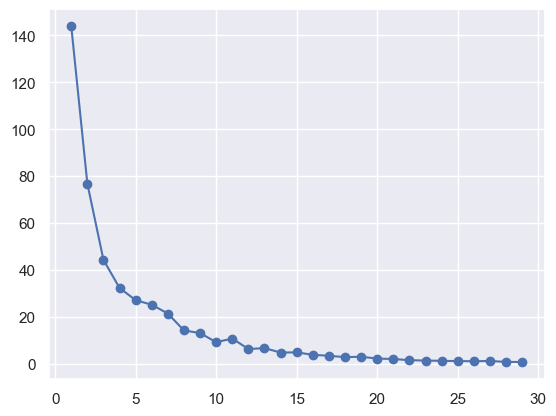

In [33]:
numbers = [i for i in range (1,30)]
plt.plot(numbers,wcss,marker='o')

In [34]:
kmeans = KMeans(10, random_state=1)
#42
kmeans.fit(X_scaled)
cluster = kmeans.fit_predict(X_scaled)

C:\Users\rajep\anaconda3\envs\climate\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\rajep\anaconda3\envs\climate\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [35]:
data['cluster'] = cluster

In [36]:
"""
plt.figure(figsize=(7,7))  # stretches x-axis

plt.scatter(
    data['Longitude'],
    data['Latitude'],
    c=data['cluster'],
    cmap='rainbow'
)

for i, city in enumerate(data['City']):
    plt.annotate(
        city,
        (data['Longitude'][i], data['Latitude'][i]),
        textcoords="offset points",
        xytext=(7,-4),
        ha='left',
        rotation=10,          # tilt labels
        fontsize=10
    )

plt.xlabel("Longitude (°)")
plt.ylabel("Latitude (°N)")
plt.title("Clustering of Indian Cities using Elevation, Distance from Himalayas, & Distance from the seas")

# Optional: add breathing room on x-axis
#plt.xlim(
 #   data['Latitude'].min() - 1,
  #  data['Latitude'].max() + 1
#)

plt.show()
"""

'\nplt.figure(figsize=(7,7))  # stretches x-axis\n\nplt.scatter(\n    data[\'Longitude\'],\n    data[\'Latitude\'],\n    c=data[\'cluster\'],\n    cmap=\'rainbow\'\n)\n\nfor i, city in enumerate(data[\'City\']):\n    plt.annotate(\n        city,\n        (data[\'Longitude\'][i], data[\'Latitude\'][i]),\n        textcoords="offset points",\n        xytext=(7,-4),\n        ha=\'left\',\n        rotation=10,          # tilt labels\n        fontsize=10\n    )\n\nplt.xlabel("Longitude (°)")\nplt.ylabel("Latitude (°N)")\nplt.title("Clustering of Indian Cities using Elevation, Distance from Himalayas, & Distance from the seas")\n\n# Optional: add breathing room on x-axis\n#plt.xlim(\n #   data[\'Latitude\'].min() - 1,\n  #  data[\'Latitude\'].max() + 1\n#)\n\nplt.show()\n'

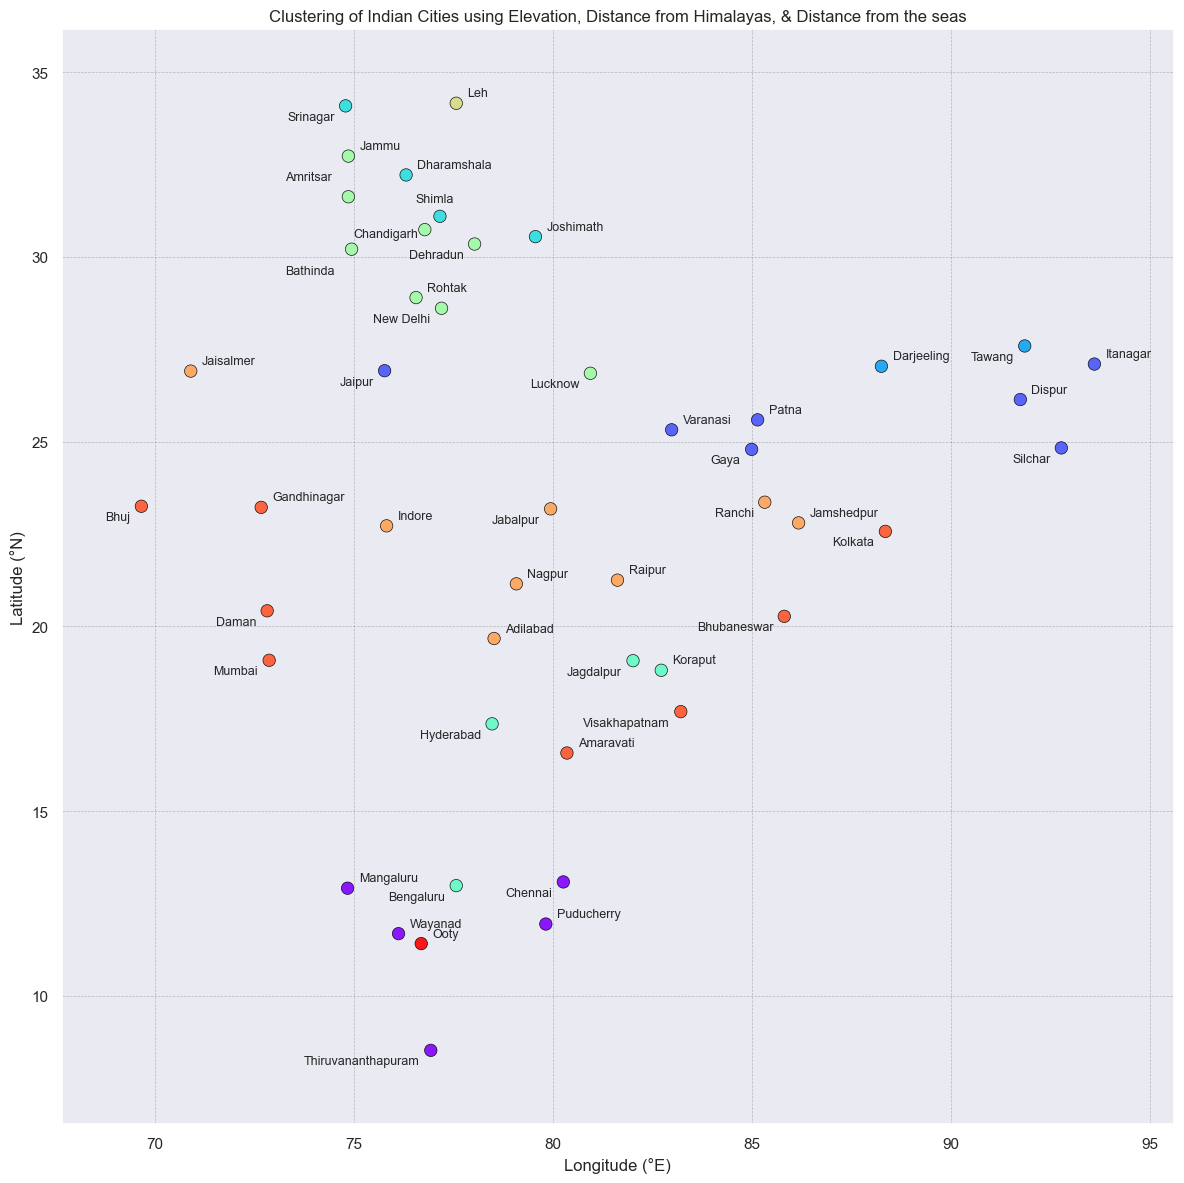

In [37]:
import matplotlib.pyplot as plt

# Increase DPI for a sharper image, especially since we have many labels
plt.figure(figsize=(12, 12), dpi=100)

# 1. Plot the points
# zorder=3 keeps the dots on top of the grid
plt.scatter(
    data['Longitude'],
    data['Latitude'],
    c=data['cluster'],
    cmap='rainbow',
    edgecolors='black',
    linewidth=0.5,
    s=80,
    alpha=0.9,
    zorder=3
)

# 2. Specific overrides for the Punjab/Haryana cluster overlap
overrides = {
    'Chandigarh': (-5, -5, 'right'),
    'Shimla': (10, 10, 'right'),
    'Bathinda': (-12, -18, 'right'),
    'Amritsar': (-12, 12, 'right'),
    'Ludhiana': (12, -12, 'left'),
    'Patiala': (12, 0, 'left')
}

for i, city in enumerate(data['City']):
    if city in overrides:
        x_off, y_off, ha = overrides[city]
    else:
        # Corrected unpacking: providing all 3 values
        if i % 2 == 0:
            x_off, y_off, ha = 8, 5, 'left'
        else:
            x_off, y_off, ha = -8, -10, 'right'
        
    plt.annotate(
        city,
        (data['Longitude'].iloc[i], data['Latitude'].iloc[i]),
        textcoords="offset points",
        xytext=(x_off, y_off),
        ha=ha,
        fontsize=9,
        zorder=4  # Keep text above everything else
    )

# 3. Add the Gridlines
# linestyle='--' makes them less distracting
# alpha=0.3 makes them subtle
plt.grid(visible=True, which='both', color='gray', linestyle='--', linewidth=0.5, alpha=0.5, zorder=0)

plt.xlabel("Longitude (°E)")
plt.ylabel("Latitude (°N)")
plt.title("Clustering of Indian Cities using Elevation, Distance from Himalayas, & Distance from the seas")

# Optional: Adjust axis limits slightly so labels on the edge aren't cut off
plt.xlim(data['Longitude'].min() - 2, data['Longitude'].max() + 2)
plt.ylim(data['Latitude'].min() - 2, data['Latitude'].max() + 2)

plt.tight_layout()
plt.show()

In [38]:
data

,State/UT,City,Latitude,Longitude,Elevation,Distance_sea,Distance_hima,is_coastal,mean_temp,annual_rainfall,mean_humidity,Distance_western,Distance_eastern,cluster
0,Andhra Pradesh,Amaravati,16.57,80.36,38,1.110380,12.377867,0,NaN,763.1,55.00,-5.509838,2.762719,8
1,Andhra Pradesh,Visakhapatnam,17.69,83.22,45,0.003534,10.383203,1,25.55,1113.1,74.00,-8.536111,-0.084791,8
2,Arunachal Pradesh,Itanagar,27.10,93.61,296,5.082735,1.511622,0,23.30,3381.2,82.00,-20.672922,12.313459,1
3,Arunachal Pradesh,Tawang,27.59,91.86,3048,5.233664,1.391294,0,5.50,2980,82.00,-19.185844,11.243504,2
4,Assam,Dispur,26.14,91.75,60,3.783246,0.078102,0,23.40,3038,78.00,-18.610576,10.295400,1
5,Assam,Silchar,24.83,92.78,22,2.666427,1.564609,0,25.60,3039.7,75.00,-19.277277,10.256245,1
6,Bihar,Patna,25.59,85.15,53,4.891265,2.286001,0,25.51,1077.6,61.00,-12.216244,5.250234,1
7,Bihar,Gaya,24.79,85.00,111,4.377045,3.080795,0,25.70,1025.5,55.00,-11.779192,4.470964,1
8,Chhattisgarh,Raipur,21.25,81.63,298,3.709240,7.545396,0,27.10,1290.3,50.00,-7.702640,-1.269761,7
9,Chhattisgarh,Jagdalpur,19.07,82.02,569,1.830203,9.502863,0,25.40,1508,58.00,-8.241854,-1.039971,4


In [39]:
# Open the .tif file
with rasterio.open(r'C:\Users\rajep\Desktop\DS\Project1\koppen_geiger_tif\1991_2020\koppen_geiger_0p00833333.tif') as src:
    
    # 1. Create a zip of your coordinates
    # Note: rasterio expects (longitude, latitude) for the sample function
    coords = zip(data['Longitude'], data['Latitude'])
    
    # 2. Sample the raster at these points
    # This is extremely fast and much better than a loop
    data['koppen_code'] = [int(val[0]) for val in src.sample(coords)]

# 3. Map the names (Optional)
#kg_map = {1: "Af", 2: "Am", 3: "Aw", 11: "Cwa", 14: "Cfa"} # Add more from the previous list
#data['koppen_name'] = data['koppen_code'].map(kg_map)

print(data[['Latitude', 'Longitude', 'koppen_code']].head())

   Latitude  Longitude  koppen_code
0     16.57      80.36            3
1     17.69      83.22            3
2     27.10      93.61           11
3     27.59      91.86           12
4     26.14      91.75           11


In [40]:
from sklearn.metrics import adjusted_mutual_info_score
from sklearn.metrics import adjusted_rand_score
from sklearn.metrics import v_measure_score, homogeneity_score, completeness_score

v = v_measure_score(data['koppen_code'], data['cluster'])
h = homogeneity_score(data['koppen_code'], data['cluster'])
c = completeness_score(data['koppen_code'], data['cluster'])
#v2 = v_measure_score(data['koppen_code'], data['cluster2'])
#h2= homogeneity_score(data['koppen_code'], data['cluster2'])
#c2= completeness_score(data['koppen_code'], data['cluster2'])

ari = adjusted_rand_score(data['koppen_code'],data['cluster']) 
#ari2 = adjusted_rand_score(data['koppen_code'],data['cluster2']) 
ami = adjusted_mutual_info_score(data['koppen_code'], data['cluster'])
#ami2 = adjusted_mutual_info_score(data['koppen_code'], data['cluster2'])
print(ari,ami,v,h,c)

0.18387945467591485 0.31270379979272034 0.524580986770111 0.5729969715034103 0.48370944588584563


In [41]:
data['koppen_code'].unique()

array([ 3, 11, 12,  2,  4,  6, 14,  7,  0], dtype=int64)

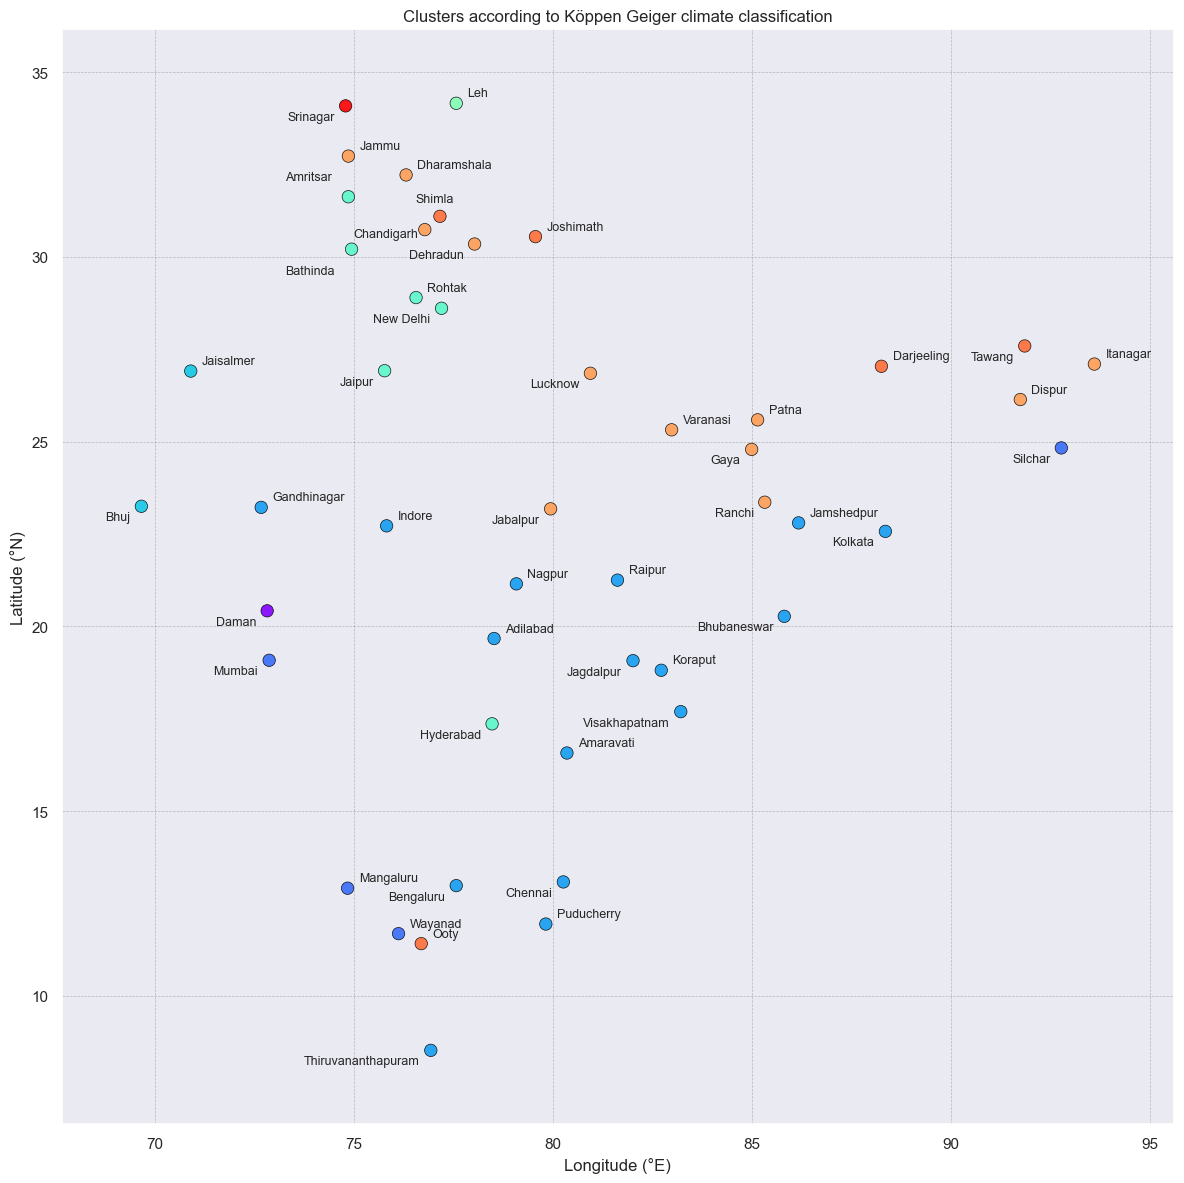

In [42]:
import matplotlib.pyplot as plt

# Increase DPI for a sharper image, especially since we have many labels
plt.figure(figsize=(12, 12), dpi=100)

# 1. Plot the points
# zorder=3 keeps the dots on top of the grid
plt.scatter(
    data['Longitude'],
    data['Latitude'],
    c= data['koppen_code'],
    cmap='rainbow',
    edgecolors='black',
    linewidth=0.5,
    s=80,
    alpha=0.9,
    zorder=3
)

# 2. Specific overrides for the Punjab/Haryana cluster overlap
overrides = {
    'Chandigarh': (-5, -5, 'right'),
    'Shimla': (10, 10, 'right'),
    'Bathinda': (-12, -18, 'right'),
    'Amritsar': (-12, 12, 'right'),
    'Ludhiana': (12, -12, 'left'),
    'Patiala': (12, 0, 'left')
}

for i, city in enumerate(data['City']):
    if city in overrides:
        x_off, y_off, ha = overrides[city]
    else:
        # Corrected unpacking: providing all 3 values
        if i % 2 == 0:
            x_off, y_off, ha = 8, 5, 'left'
        else:
            x_off, y_off, ha = -8, -10, 'right'
        
    plt.annotate(
        city,
        (data['Longitude'].iloc[i], data['Latitude'].iloc[i]),
        textcoords="offset points",
        xytext=(x_off, y_off),
        ha=ha,
        fontsize=9,
        zorder=4  # Keep text above everything else
    )

# 3. Add the Gridlines
# linestyle='--' makes them less distracting
# alpha=0.3 makes them subtle
plt.grid(visible=True, which='both', color='gray', linestyle='--', linewidth=0.5, alpha=0.5, zorder=0)

plt.xlabel("Longitude (°E)")
plt.ylabel("Latitude (°N)")
plt.title("Clusters according to Köppen Geiger climate classification")

# Optional: Adjust axis limits slightly so labels on the edge aren't cut off
plt.xlim(data['Longitude'].min() - 2, data['Longitude'].max() + 2)
plt.ylim(data['Latitude'].min() - 2, data['Latitude'].max() + 2)

plt.tight_layout()
plt.show()

In [43]:
features_result = ['City', 'mean_temp','annual_rainfall', 'mean_humidity', 'cluster', 'koppen_code']
result_data = data[features_result]


In [49]:
print(result_data['annual_rainfall'].dtype)
# Convert the column to numbers
result_data['annual_rainfall'] = pd.to_numeric(result_data['annual_rainfall'], errors='coerce')

# Now run your groupby
result_data['cluster_annual_rainfall'] = result_data.groupby('cluster')['annual_rainfall'].transform('mean')

object


In [51]:
result_data['cluster_mean_temp'] = result_data.groupby('cluster')['mean_temp'].transform('mean')
#result_data['cluster2_mean_temp'] = result_data.groupby('cluster2')['mean_temp'].transform('mean')
result_data['koppen_mean_temp'] = result_data.groupby('koppen_code')['mean_temp'].transform('mean')
result_data['cluster_mean_humidity'] = result_data.groupby('cluster')['mean_humidity'].transform('mean')
#result_data['cluster2_mean_humidity'] = result_data.groupby('cluster2')['mean_humidity'].transform('mean')
result_data['koppen_mean_humidity'] = result_data.groupby('koppen_code')['mean_humidity'].transform('mean')
result_data['cluster_annual_rainfall'] = result_data.groupby('cluster')['annual_rainfall'].transform('mean')
#result_data['cluster2_annual_rainfall'] = result_data.groupby('cluster2')['annual_rainfall'].transform('mean')
result_data['koppen_annual_rainfall'] = result_data.groupby('koppen_code')['annual_rainfall'].transform('mean')


In [53]:
result_data.columns

Index(['City', 'mean_temp', 'annual_rainfall', 'mean_humidity', 'cluster',
       'koppen_code', 'cluster_mean_temp', 'koppen_mean_temp',
       'cluster_mean_humidity', 'koppen_mean_humidity',
       'cluster_annual_rainfall', 'koppen_annual_rainfall'],
      dtype='str')

In [55]:
updated = ['City', 'mean_temp', 'cluster_mean_temp', 'koppen_mean_temp','annual_rainfall', 'cluster_annual_rainfall', 'koppen_annual_rainfall','mean_humidity', 'cluster_mean_humidity', 'koppen_mean_humidity','cluster', 'koppen_code']
result_data = result_data[updated]

In [57]:
result_data['temp_diff1'] = result_data['mean_temp'] - result_data['cluster_mean_temp']
#result_data['temp_diff2'] = result_data['mean_temp'] - result_data['cluster2_mean_temp']
result_data['temp_diff3'] = result_data['mean_temp'] - result_data['koppen_mean_temp']
result_data['humi_diff1'] = result_data['mean_humidity'] - result_data['cluster_mean_humidity']
#result_data['humi_diff2'] = result_data['mean_humidity'] - result_data['cluster2_mean_humidity']
result_data['humi_diff3'] = result_data['mean_humidity'] - result_data['koppen_mean_humidity']
result_data['rain_diff1'] = result_data['annual_rainfall'] - result_data['cluster_annual_rainfall']
#result_data['rain_diff2'] = result_data['annual_rainfall'] - result_data['cluster2_annual_rainfall']
result_data['rain_diff3'] = result_data['annual_rainfall'] - result_data['koppen_annual_rainfall']

In [59]:
result_data

,City,mean_temp,cluster_mean_temp,koppen_mean_temp,annual_rainfall,cluster_annual_rainfall,koppen_annual_rainfall,mean_humidity,cluster_mean_humidity,koppen_mean_humidity,cluster,koppen_code,temp_diff1,temp_diff3,humi_diff1,humi_diff3,rain_diff1,rain_diff3
0,Amaravati,NaN,27.185714,26.604667,763.1,1326.687500,1298.262500,55.00,61.5725,61.597500,8,3,NaN,NaN,-6.5725,-6.597500,-563.587500,-535.162500
1,Visakhapatnam,25.55,27.185714,26.604667,1113.1,1326.687500,1298.262500,74.00,61.5725,61.597500,8,3,-1.635714,-1.054667,12.4275,12.402500,-213.587500,-185.162500
2,Itanagar,23.30,25.041429,23.790000,3381.2,1878.314286,1730.941667,82.00,64.0000,60.833333,1,11,-1.741429,-0.490000,18.0000,21.166667,1502.885714,1650.258333
3,Tawang,5.50,9.420000,9.974000,2980.0,3040.000000,1965.760000,82.00,82.2100,73.484000,2,12,-3.920000,-4.474000,-0.2100,8.516000,-60.000000,1014.240000
4,Dispur,23.40,25.041429,23.790000,3038.0,1878.314286,1730.941667,78.00,64.0000,60.833333,1,11,-1.641429,-0.390000,14.0000,17.166667,1159.685714,1307.058333
5,Silchar,25.60,25.041429,26.357500,3039.7,1878.314286,3009.066667,75.00,64.0000,75.250000,1,2,0.558571,-0.757500,11.0000,-0.250000,1161.385714,30.633333
6,Patna,25.51,25.041429,23.790000,1077.6,1878.314286,1730.941667,61.00,64.0000,60.833333,1,11,0.468571,1.720000,-3.0000,0.166667,-800.714286,-653.341667
7,Gaya,25.70,25.041429,23.790000,1025.5,1878.314286,1730.941667,55.00,64.0000,60.833333,1,11,0.658571,1.910000,-9.0000,-5.833333,-852.814286,-705.441667
8,Raipur,27.10,26.282500,26.604667,1290.3,1111.287500,1298.262500,50.00,49.5000,61.597500,7,3,0.817500,0.495333,0.5000,-11.597500,179.012500,-7.962500
9,Jagdalpur,25.40,24.775000,26.604667,1508.0,1262.850000,1298.262500,58.00,58.1500,61.597500,4,3,0.625000,-1.204667,-0.1500,-3.597500,245.150000,209.737500


In [61]:
result_data.columns

Index(['City', 'mean_temp', 'cluster_mean_temp', 'koppen_mean_temp',
       'annual_rainfall', 'cluster_annual_rainfall', 'koppen_annual_rainfall',
       'mean_humidity', 'cluster_mean_humidity', 'koppen_mean_humidity',
       'cluster', 'koppen_code', 'temp_diff1', 'temp_diff3', 'humi_diff1',
       'humi_diff3', 'rain_diff1', 'rain_diff3'],
      dtype='str')

In [63]:
result_data[['City', 'temp_diff1', 'temp_diff3', 'humi_diff1','humi_diff3','rain_diff1','rain_diff3' ]]

,City,temp_diff1,temp_diff3,humi_diff1,humi_diff3,rain_diff1,rain_diff3
0,Amaravati,NaN,NaN,-6.5725,-6.597500,-563.587500,-535.162500
1,Visakhapatnam,-1.635714,-1.054667,12.4275,12.402500,-213.587500,-185.162500
2,Itanagar,-1.741429,-0.490000,18.0000,21.166667,1502.885714,1650.258333
3,Tawang,-3.920000,-4.474000,-0.2100,8.516000,-60.000000,1014.240000
4,Dispur,-1.641429,-0.390000,14.0000,17.166667,1159.685714,1307.058333
5,Silchar,0.558571,-0.757500,11.0000,-0.250000,1161.385714,30.633333
6,Patna,0.468571,1.720000,-3.0000,0.166667,-800.714286,-653.341667
7,Gaya,0.658571,1.910000,-9.0000,-5.833333,-852.814286,-705.441667
8,Raipur,0.817500,0.495333,0.5000,-11.597500,179.012500,-7.962500
9,Jagdalpur,0.625000,-1.204667,-0.1500,-3.597500,245.150000,209.737500


In [65]:
print(result_data['temp_diff1'].var(),result_data['temp_diff3'].var())
print(result_data['humi_diff1'].var(),result_data['humi_diff3'].var())
print(result_data['rain_diff1'].var(),result_data['rain_diff3'].var())

4.434433687888199 5.237363079710146
83.34839531914893 82.25360893617021
486159.5517624224 355734.8495362319


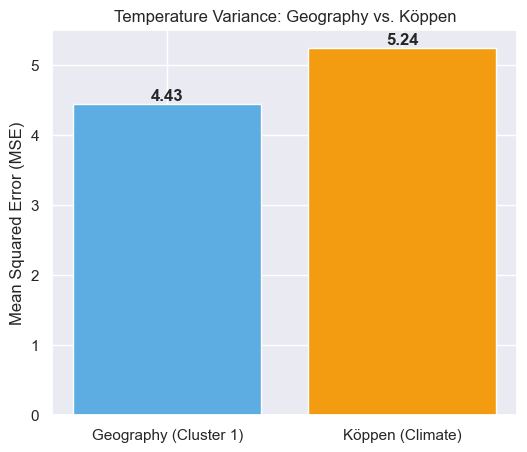

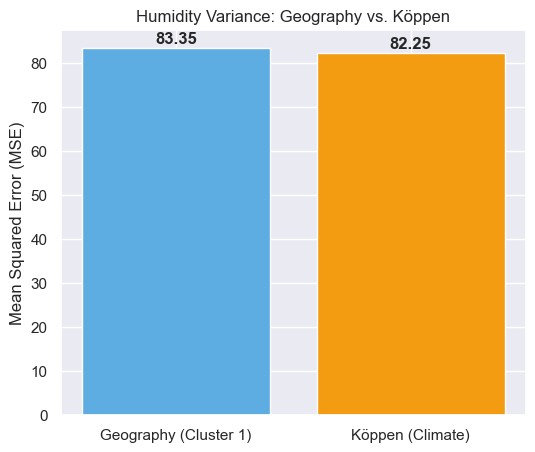

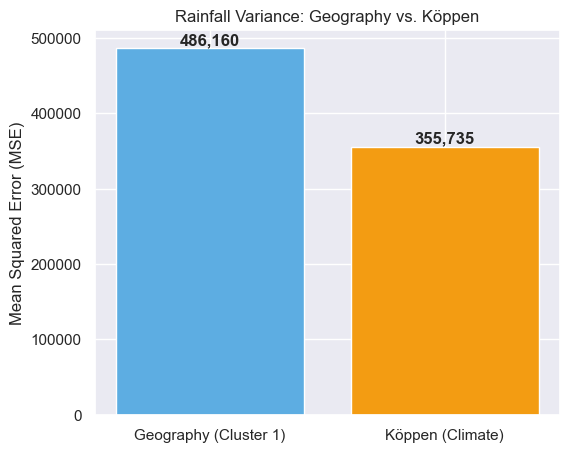

In [76]:
import matplotlib.pyplot as plt

# Data constants from your analysis
# Format: [Geography (Cluster 1), Köppen (Climate)]
temp_vals = [result_data['temp_diff1'].var(),result_data['temp_diff3'].var()]
humi_vals = [result_data['humi_diff1'].var(),result_data['humi_diff3'].var()]
rain_vals = [result_data['rain_diff1'].var(),result_data['rain_diff3'].var()]

labels = ['Geography (Cluster 1)', 'Köppen (Climate)']
colors = ['#5dade2', '#f39c12'] # Skyblue and Orange

# 1. Temperature Variance Graph
fig1, ax1 = plt.subplots(figsize=(6, 5))
ax1.bar(labels, temp_vals, color=colors)
ax1.set_title('Temperature Variance: Geography vs. Köppen')
ax1.set_ylabel('Mean Squared Error (MSE)')
for i, v in enumerate(temp_vals):
    ax1.text(i, v + 0.05, f'{v:.2f}', ha='center', fontweight='bold')
plt.savefig('temp_variance_plot.png')

# 2. Humidity Variance Graph
fig2, ax2 = plt.subplots(figsize=(6, 5))
ax2.bar(labels, humi_vals, color=colors)
ax2.set_title('Humidity Variance: Geography vs. Köppen')
ax2.set_ylabel('Mean Squared Error (MSE)')
for i, v in enumerate(humi_vals):
    ax2.text(i, v + 1, f'{v:.2f}', ha='center', fontweight='bold')
plt.savefig('humidity_variance_plot.png')

# 3. Rainfall Variance Graph
fig3, ax3 = plt.subplots(figsize=(6, 5))
ax3.bar(labels, rain_vals, color=colors)
ax3.set_title('Rainfall Variance: Geography vs. Köppen')
ax3.set_ylabel('Mean Squared Error (MSE)')
for i, v in enumerate(rain_vals):
    ax3.text(i, v + 5000, f'{v:,.0f}', ha='center', fontweight='bold')
plt.savefig('rainfall_variance_plot.png')

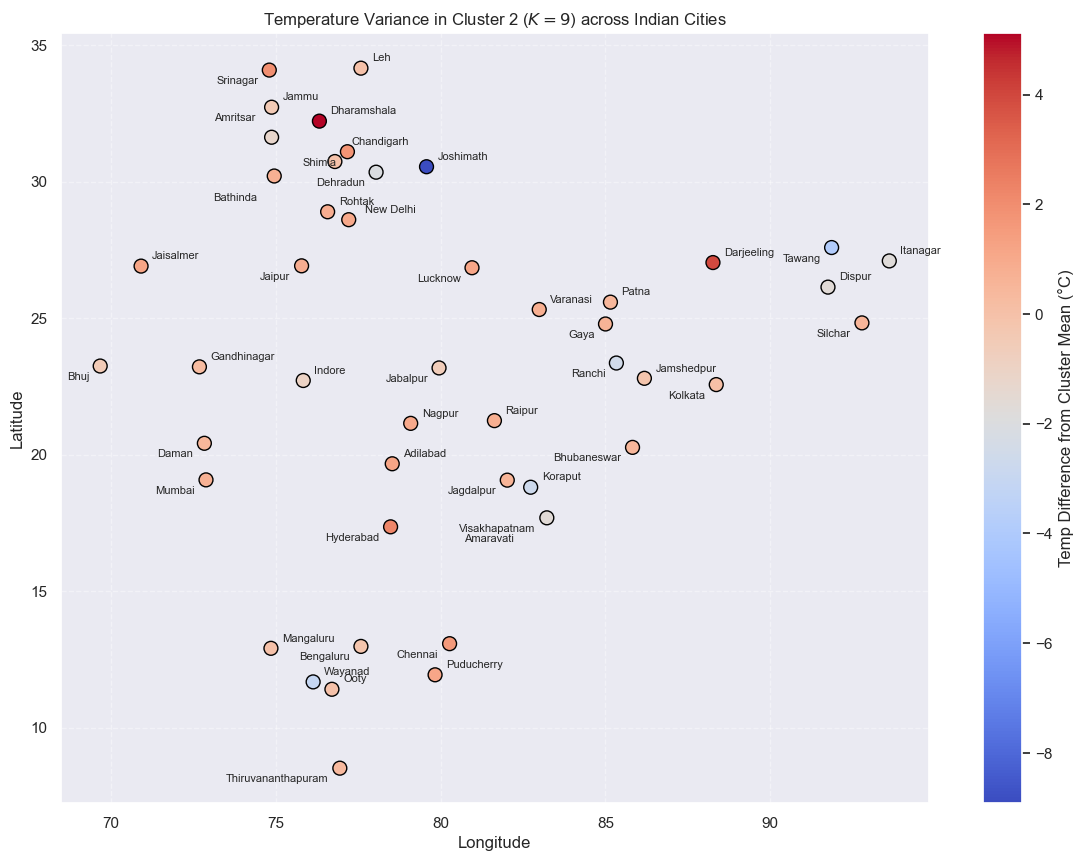

In [78]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 10), dpi=100)

# 1. Scatter plot using temp_diff2 as the color
# This will show you which cities 'fit' their cluster well (near 0) 
# and which are outliers (high positive or negative values)
scatter = plt.scatter(
    data['Longitude'], 
    data['Latitude'], 
    c=result_data['temp_diff1'], 
    cmap='coolwarm', # Blue for colder than cluster avg, Red for hotter
    s=100, 
    edgecolors='black',
    zorder=3
)

# Add a colorbar to explain the 'diff' values
cbar = plt.colorbar(scatter)
cbar.set_label('Temp Difference from Cluster Mean (°C)')

# 2. Add labels with the overlap fix
overrides = {
    'Chandigarh': (12, 12, 'left'),
    'Bathinda': (-12, -18, 'right'),
    'Amritsar': (-12, 12, 'right'),
    'Ludhiana': (12, -12, 'left'),
    'New Delhi': (12, 5, 'left')
}

for i in range(len(result_data)):
    city = result_data['City'].iloc[i]
    if city in overrides:
        x_off, y_off, ha = overrides[city]
    else:
        x_off, y_off, ha = (8, 5, 'left') if i % 2 == 0 else (-8, -10, 'right')
        
    plt.annotate(
        city,
        (data['Longitude'].iloc[i], data['Latitude'].iloc[i]),
        textcoords="offset points",
        xytext=(x_off, y_off),
        ha=ha,
        fontsize=8,
        zorder=4
    )

# 3. Final Touches
plt.grid(visible=True, linestyle='--', alpha=0.4, zorder=0)
plt.title("Temperature Variance in Cluster 2 ($K=9$) across Indian Cities")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

In [80]:
# Calculating squared errors for each feature in Cluster 2
result_data['sq_diff_temp'] = result_data['temp_diff1']**2
result_data['sq_diff_humi'] = result_data['humi_diff1']**2
result_data['sq_diff_rain'] = result_data['rain_diff1']**2

# Total SSE for the entire K=9 model
total_sse = (result_data['sq_diff_temp'] + 
             result_data['sq_diff_humi'] + 
             result_data['sq_diff_rain']).sum()

print(f"Total SSE for Cluster 2 (K=9): {total_sse:,.2f}")

# Optional: See which cluster is the 'loosest' (highest variance)
cluster_variance = result_data.groupby('cluster')[['sq_diff_temp', 'sq_diff_humi', 'sq_diff_rain']].sum()
print("\nSSE per Cluster:")
print(cluster_variance.sum(axis=1))

Total SSE for Cluster 2 (K=9): 22,049,745.69

SSE per Cluster:
cluster
0    3.905904e+06
1    8.751953e+06
2    7.230821e+03
3    3.108752e+06
4    3.751285e+05
5    2.061621e+06
6    0.000000e+00
7    1.100167e+06
8    3.056705e+06
9    0.000000e+00
dtype: float64


Adjusted Mutual Information (AMI) between Geography and Climate: 0.3127


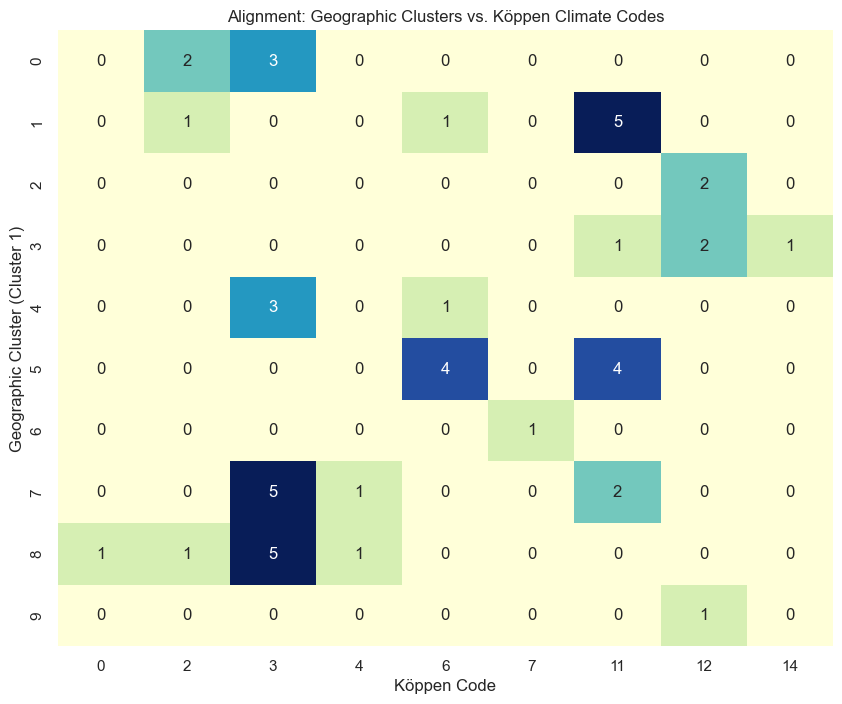

In [82]:
import pandas as pd
from sklearn.metrics import adjusted_mutual_info_score
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calculate the Adjusted Mutual Information (AMI) Score
# This is your 'Final Grade' for the geographic model's predictive power
ami_score = adjusted_mutual_info_score(result_data['koppen_code'], result_data['cluster'])
print(f"Adjusted Mutual Information (AMI) between Geography and Climate: {ami_score:.4f}")

# 2. Create a Crosstab (Confusion Matrix)
# This shows exactly where the classifications align or diverge
ct = pd.crosstab(result_data['cluster'], result_data['koppen_code'])

# 3. Visualize the overlap with a Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(ct, annot=True, fmt='d', cmap='YlGnBu', cbar=False)
plt.title("Alignment: Geographic Clusters vs. Köppen Climate Codes")
plt.xlabel("Köppen Code")
plt.ylabel("Geographic Cluster (Cluster 1)")
plt.show()